In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import plot, Function
from utils.problem_setup import TestProblemsSetup
from utils.utils import progress_bar, disk_cache
from utils.metrics import error_movers, error_auc_iou
from algorithms.rsvd_solvers import MatrixFreeRSVD, MatrixFreeRSVDAdjoint

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

RESULTS_FOLDER = '../../results/rsvdAdjoint_error'
PROBLEMS = TestProblemsSetup(n=32).get_test_problems()
SEED = 15

In [71]:
def compute_errors(
    k: int, x: np.ndarray, x_hat: np.ndarray, x_hat_adj: np.ndarray
) -> dict[str, float]:
    return {
        'k': k,
        'rsvd_euc': np.linalg.norm(x - x_hat),
        'rsvdAdj_euc': np.linalg.norm(x - x_hat_adj),
        'rsvd_emd': error_movers(x, x_hat),
        'rsvdAdj_emd': error_movers(x, x_hat_adj),
        'rsvd_auc_iou': error_auc_iou(x, x_hat)[0],
        'rsvdAdj_auc_iou': error_auc_iou(x, x_hat_adj)[0]
    }


@disk_cache(RESULTS_FOLDER)
def experiment(k_range: np.ndarray, pid: str, lam: float = 1e-4, repeat: int = 1):
    pb = PROBLEMS[pid]

    results = []
    n_steps, step = len(k_range) * repeat, 1
    for k in k_range:
        rsvd = MatrixFreeRSVD(pb['V_h'])
        rsvd_adj = MatrixFreeRSVDAdjoint(pb['V_h'])

        for r in range(repeat):
            progress_bar(step, n_steps)
            step += 1

            # Solve via the rSVD
            rsvd.solve(k=k, seed=SEED + r)
            x_hat = rsvd.tikhonov_solve(y=pb['y'], w=rsvd.weights(), lam=lam)

            # Solve via the adjoint rSVD
            rsvd_adj.solve(k=k, seed=SEED + r)
            rsvd_adj.recover_K()
            x_hat_adj = rsvd_adj.tikhonov_solve(y=pb['y'], w=rsvd_adj.weights(), lam=lam)

            results.append(compute_errors(k, pb['x'], x_hat, x_hat_adj))
    
    return pd.DataFrame(results)


In [72]:
k_range = np.arange(5, 100)
repeat = 50
params = [
    {'k_range': k_range, 'pid': 'I',   'repeat': repeat},
    {'k_range': k_range, 'pid': 'II' , 'repeat': repeat},
    {'k_range': k_range, 'pid': 'III', 'repeat': repeat}
]
results = [{'params': p, 'df': experiment(**p)} for p in params]

../../figures/rsvd_adjoint_error_I.png already exists


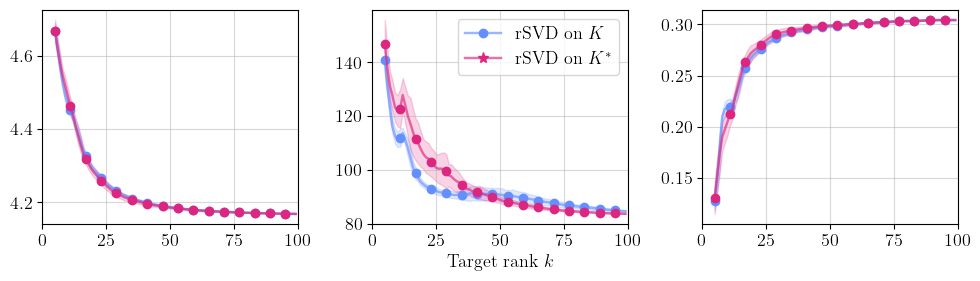

../../figures/rsvd_adjoint_error_II.png already exists


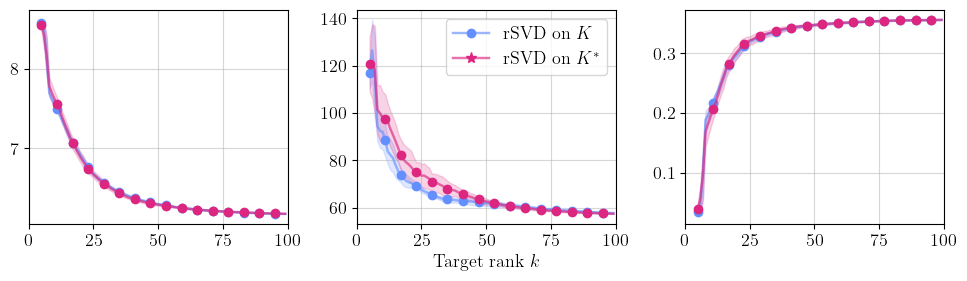

../../figures/rsvd_adjoint_error_III.png already exists


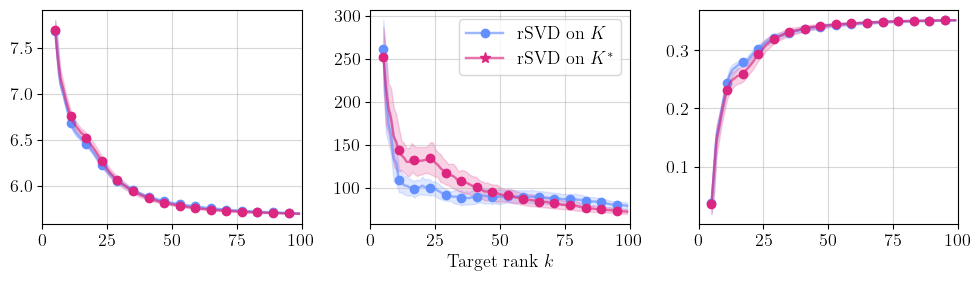

In [73]:
def plot_df(df, fig_name=None):   
    from utils.colors import C2, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    s = 6
    dists = ['euc', 'emd', 'auc_iou']

    for dist, ax in zip(dists, axes.flat):
        # Mean and std
        mean_rsvd = df[f'rsvd_{dist}_mean']
        std_rsvd  = df[f'rsvd_{dist}_std']

        mean_adj = df[f'rsvdAdj_{dist}_mean']
        std_adj  = df[f'rsvdAdj_{dist}_std']

        # rSVD
        ax.plot(df.k, mean_rsvd, c=C2[0], lw=1.75, alpha=.65)
        ax.fill_between(
            df.k,
            mean_rsvd - std_rsvd,
            mean_rsvd + std_rsvd,
            color=C2[0],
            alpha=0.2
        )

        # markers
        ax.plot(df.k[::s], mean_rsvd[::s], M[0], ms=MS[0], c=C2[0])

        # rSVD adjoint
        ax.plot(df.k, mean_adj, c=C2[1], lw=1.75, alpha=.65)
        ax.fill_between(
            df.k,
            mean_adj - std_adj,
            mean_adj + std_adj,
            color=C2[1],
            alpha=0.2
        )

        ax.plot(df.k[::s], mean_adj[::s], M[0], ms=MS[0], c=C2[1])

        ax.set_xlim(0, 100)
        ax.locator_params(axis='x', nbins=4)
        ax.grid(True, alpha=0.5)

    # legend unchanged
    handles, labels = [], ['rSVD on $K$', 'rSVD on $K^*$']
    for i in range(2):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=1.75, alpha=0.65)
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    axes[1].set_xlabel("Target rank $k$")
    axes[1].legend(handles=handles, labels=labels)

    plt.tight_layout()
    save_plot(fig_name)
    plt.show()

for result in results:
    params = result['params']

    df_grouped = result['df'].groupby('k').agg(['mean', 'std']).reset_index()
    df_grouped.columns = [
        f"{c[0]}_{c[1]}" if c[1] else c[0]
        for c in df_grouped.columns
    ]

    plot_df(df_grouped, f"rsvd_adjoint_error_{params['pid']}")


In [74]:
results[0]['df']

,k,rsvd_euc,rsvdAdj_euc,rsvd_emd,rsvdAdj_emd,rsvd_auc_iou,rsvdAdj_auc_iou
0,5,4.634093,4.649380,134.230699,136.428808,0.138662,0.136266
1,5,4.705616,4.624332,147.414797,130.389100,0.112103,0.142727
2,5,4.662188,4.636866,138.416859,140.916104,0.130950,0.153348
3,5,4.669847,4.738803,140.212079,166.118638,0.125290,0.098147
4,5,4.641026,4.683764,133.880982,155.749909,0.134147,0.127997
...,...,...,...,...,...,...,...
4745,99,4.167912,4.167929,84.091495,83.683547,0.303989,0.304290
4746,99,4.167788,4.168593,83.925520,83.609644,0.303748,0.304258
4747,99,4.168092,4.168801,85.091958,83.711554,0.303849,0.304220
4748,99,4.168094,4.168230,84.370202,83.628773,0.304648,0.304454


In [75]:
means = []
for r in results:
    df = r['df']
    means.append(
        df.groupby('k').agg('mean').reset_index()
    )

In [79]:
dists = ['euc', 'emd', 'auc_iou']
ks = [10, 25, 50, 75, 99]
c = -100  # percentage scaling

dfI, dfII, dfIII = means  # unpack once

for k in ks:
    row_vals = []

    for d in dists:
        if d == 'auc_iou': c*= -1
        
        rel_I = c * (dfI[f'rsvdAdj_{d}']   - dfI[f'rsvd_{d}'])   / dfI[f'rsvd_{d}']
        rel_II = c * (dfII[f'rsvdAdj_{d}'] - dfII[f'rsvd_{d}'])  / dfII[f'rsvd_{d}']
        rel_III = c * (dfIII[f'rsvdAdj_{d}'] - dfIII[f'rsvd_{d}']) / dfIII[f'rsvd_{d}']

        k_idx = dfI.index[dfI.k == k][0]

        row_vals.extend([
            f"{rel_I[k_idx]:.2f}",
            f"{rel_II[k_idx]:.2f}",
            f"{rel_III[k_idx]:.2f}",
        ])

    row_str = " & ".join(row_vals)
    print(f"{k} & {row_str} \\\\")

10 & -0.50 & -0.76 & -0.80 & -9.66 & -6.52 & -19.01 & -6.48 & -4.69 & -3.52 \\
25 & -0.17 & -0.13 & 0.39 & 9.27 & 8.75 & 30.63 & -1.36 & -0.63 & 2.05 \\
50 & 0.02 & 0.11 & 0.22 & 2.10 & -1.11 & -2.74 & 0.24 & 0.02 & 0.07 \\
75 & 0.00 & 0.02 & -0.18 & -2.41 & -0.86 & -7.94 & 0.01 & -0.00 & -0.04 \\
99 & -0.01 & -0.03 & 0.07 & 1.10 & 0.51 & 8.57 & -0.00 & -0.00 & 0.04 \\


In [77]:
PROBLEMS = TestProblemsSetup(n=64).get_test_problems()


def double_solve(k: int, pid: str):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd_adj = MatrixFreeRSVDAdjoint(pb['V_h'])

    rsvd.solve(k=k, seed=SEED)
    rsvd_adj.solve(k=k)
    rsvd_adj.recover_K()

    x_hat = rsvd.tikhonov_solve(pb['y'], rsvd.weights(), lam=1e-4)
    x_hat_adj = rsvd_adj.tikhonov_solve(pb['y'], rsvd_adj.weights(), lam=1e-4)

    f_hat = Function(pb['V_h'])
    f_hat_adj = Function(pb['V_h'])

    f_hat.vector()[:] = x_hat
    f_hat_adj.vector()[:] = x_hat_adj

    return [f_hat, f_hat_adj]


f_dict = {pid: double_solve(k=15, pid=pid) for pid in ['I', 'II', 'III']}
f_list1 = [f[0] for f in f_dict.values()]
f_list2 = [f[1] for f in f_dict.values()]



../../figures/clipped_solution_K.png already exists


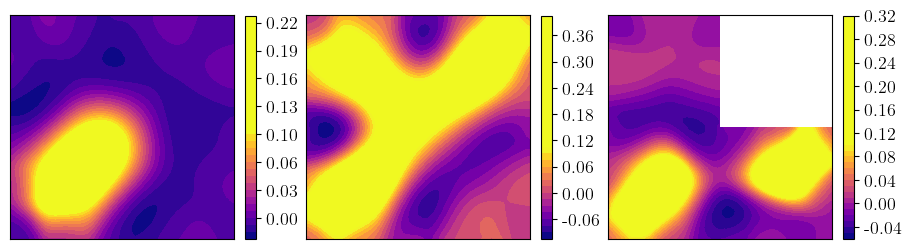

../../figures/clipped_solution_K_star.png already exists


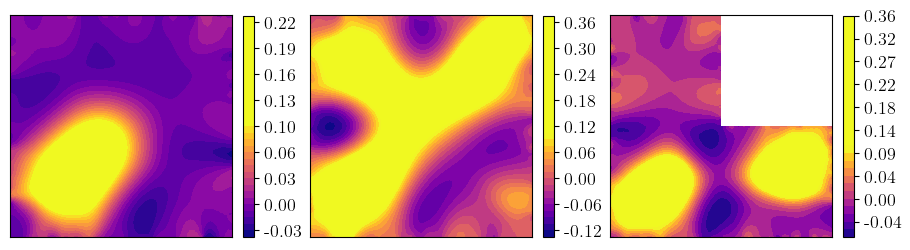

In [78]:

from utils.colors import CMAP
from utils.plotting import save_plot

def plot_multiple_f(f_list, names=None, fig_name=None, shrink=0.3):
    fig, axes = plt.subplots(1, 3, figsize=(9, 6.06), constrained_layout=True)

    if names is None:
        names = ['' for _ in axes.flat]

    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        vmin = np.min(func.vector().get_local())

        p = plot(func, title=name, cmap=CMAP, vmin=vmin, vmax=0.1)
        fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

    #axes[0][0].set_ylabel('rSVD $K$')
    #axes[1][0].set_ylabel('rSVD $K^*$')
    #axes[1][0].set_xlabel('Problem I')
    #axes[1][1].set_xlabel('Problem II')
    #axes[1][2].set_xlabel('Problem III')
    save_plot(fig_name=fig_name)
    plt.show()

plot_multiple_f(f_list1, fig_name='clipped_solution_K', shrink=0.373)
plot_multiple_f(f_list2, fig_name='clipped_solution_K_star', shrink=0.370)